In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('heart.csv' )

In [3]:
df.head()


,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Age             918 non-null    int64  
 1   Sex             918 non-null    object 
 2   ChestPainType   918 non-null    object 
 3   RestingBP       918 non-null    int64  
 4   Cholesterol     918 non-null    int64  
 5   FastingBS       918 non-null    int64  
 6   RestingECG      918 non-null    object 
 7   MaxHR           918 non-null    int64  
 8   ExerciseAngina  918 non-null    object 
 9   Oldpeak         918 non-null    float64
 10  ST_Slope        918 non-null    object 
 11  HeartDisease    918 non-null    int64  
dtypes: float64(1), int64(6), object(5)
memory usage: 86.2+ KB


In [5]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,Oldpeak,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.887364,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,1.066570,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,-2.600000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,0.600000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.500000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,6.200000,1.000000


In [6]:
df.isnull().sum()

Age               0
Sex               0
ChestPainType     0
RestingBP         0
Cholesterol       0
FastingBS         0
RestingECG        0
MaxHR             0
ExerciseAngina    0
Oldpeak           0
ST_Slope          0
HeartDisease      0
dtype: int64

In [7]:
df.dtypes

Age                 int64
Sex                object
ChestPainType      object
RestingBP           int64
Cholesterol         int64
FastingBS           int64
RestingECG         object
MaxHR               int64
ExerciseAngina     object
Oldpeak           float64
ST_Slope           object
HeartDisease        int64
dtype: object

In [8]:
df.duplicated().sum()

np.int64(0)

In [9]:
df.drop(columns=['Oldpeak' , 'ST_Slope'] , axis= 1, inplace=True)

In [10]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0
1,49,F,NAP,160,180,0,Normal,156,N,1
2,37,M,ATA,130,283,0,ST,98,N,0
3,48,F,ASY,138,214,0,Normal,108,Y,1
4,54,M,NAP,150,195,0,Normal,122,N,0


In [11]:
df['HeartDisease'].value_counts()

HeartDisease
1    508
0    410
Name: count, dtype: int64

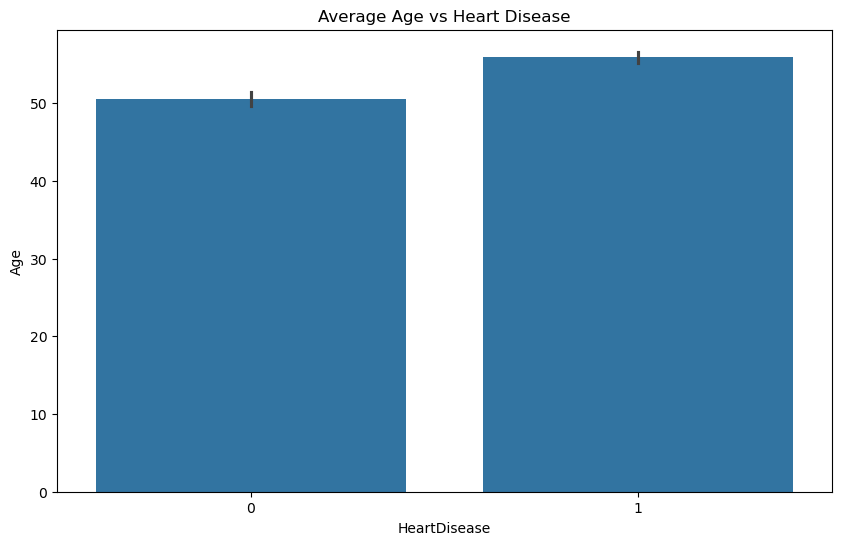

In [12]:
plt.figure(figsize = (10 , 6))
sns.barplot(x='HeartDisease', y='Age', data=df)
plt.title("Average Age vs Heart Disease")
plt.show()

In [13]:
df.columns

Index(['Age', 'Sex', 'ChestPainType', 'RestingBP', 'Cholesterol', 'FastingBS',
       'RestingECG', 'MaxHR', 'ExerciseAngina', 'HeartDisease'],
      dtype='object')

In [14]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.396514,198.799564,0.233115,136.809368,0.553377
std,9.432617,18.514154,109.384145,0.423046,25.460334,0.497414
min,28.000000,0.000000,0.000000,0.000000,60.000000,0.000000
25%,47.000000,120.000000,173.250000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,223.000000,0.000000,138.000000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,1.000000


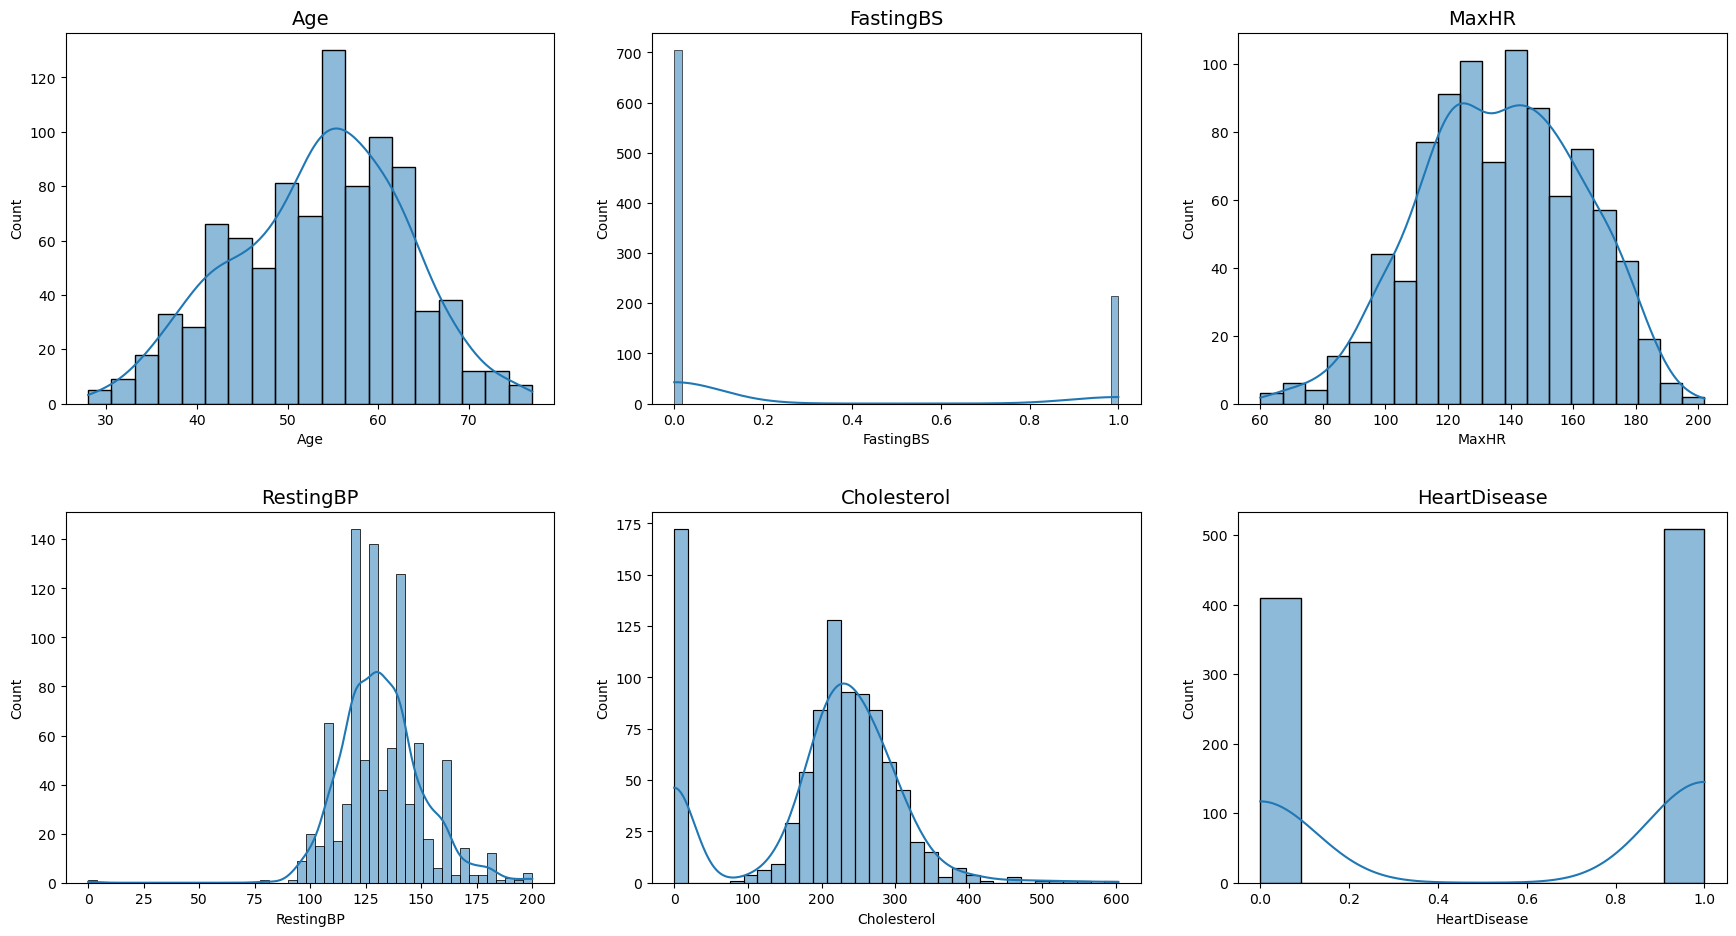

In [15]:
plt.figure(figsize=(18, 10))

def plotting(var, num):
    plt.subplot(2, 3, num)
    sns.histplot(df[var], kde=True, bins='auto')
    plt.title(var, fontsize=14)

plotting('Age', 1)
plotting('FastingBS', 2)
plotting('MaxHR', 3)
plotting('RestingBP', 4)
plotting('Cholesterol', 5)
plotting('HeartDisease', 6)

plt.tight_layout(pad=3)
plt.show()
    

In [16]:
#changing thr value of restingBP and Cholesterol
BP_mean = df.loc[df['RestingBP'] != 0, 'RestingBP'].mean()
print(BP_mean)

132.54089422028352


In [17]:
df['RestingBP'] = df['RestingBP'].replace(0 , BP_mean)
df['RestingBP'] = df['RestingBP'].round(2)

In [18]:
ch_mean = df.loc[df['Cholesterol'] != 0 , 'Cholesterol'].mean()
print(ch_mean)

244.6353887399464


In [19]:
df['Cholesterol'] = df['Cholesterol'].replace(0 , ch_mean)
df['Cholesterol'] = df['Cholesterol'].round(2)

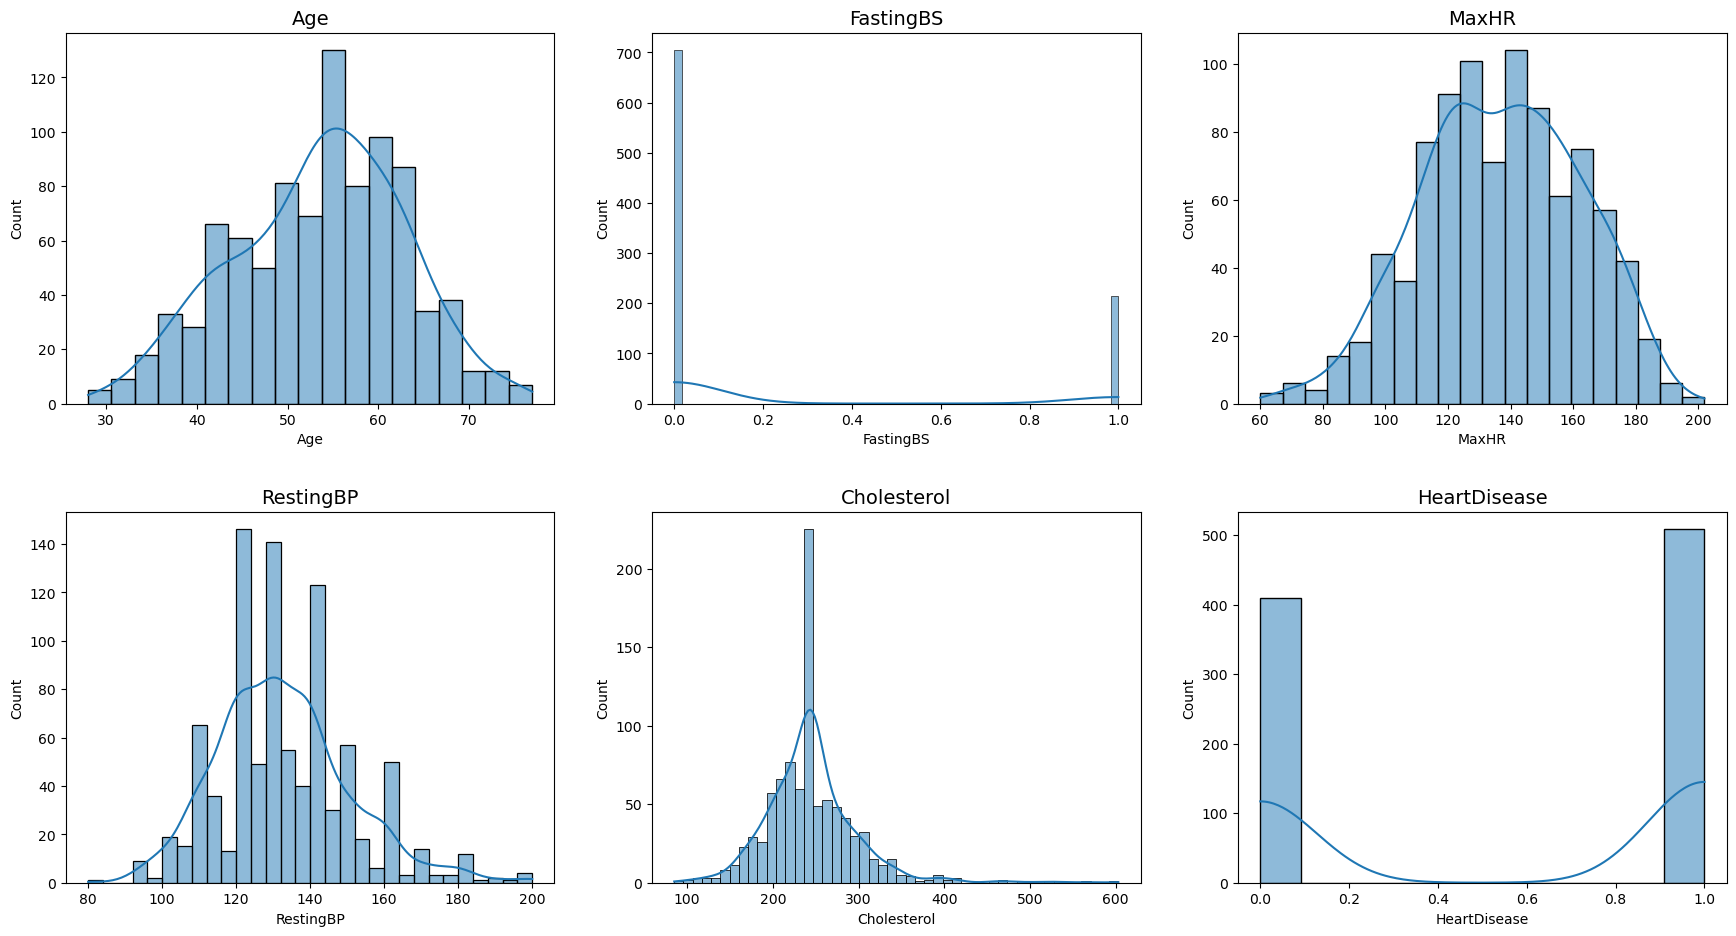

In [20]:
#checking by smae plotting
plt.figure(figsize=(18, 10))

def plotting(var, num):
    plt.subplot(2, 3, num)
    sns.histplot(df[var], kde=True, bins='auto')
    plt.title(var, fontsize=14)

plotting('Age', 1)
plotting('FastingBS', 2)
plotting('MaxHR', 3)
plotting('RestingBP', 4)
plotting('Cholesterol', 5)
plotting('HeartDisease', 6)

plt.tight_layout(pad=3)
plt.savefig('sub_plot.png' , dpi = 300 , bbox_inches = 'tight')
plt.show()

In [21]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0


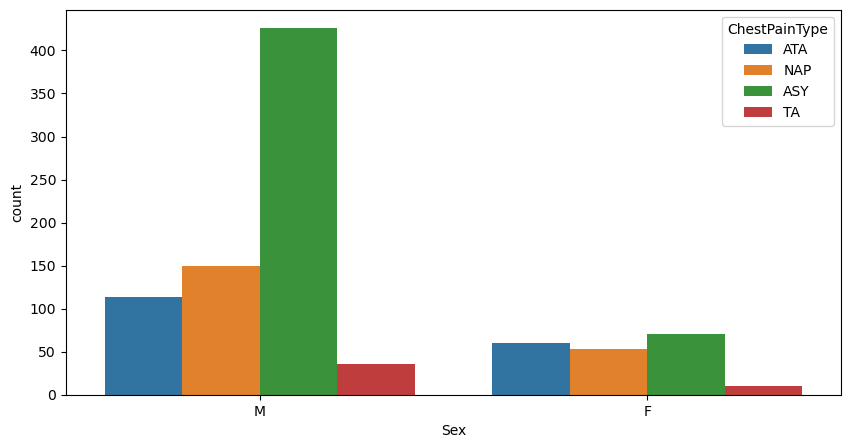

In [22]:
#graph on based sex
plt.figure(figsize= (10 , 5))
sns.countplot(x = 'Sex' , data = df , hue= 'ChestPainType')
plt.show()

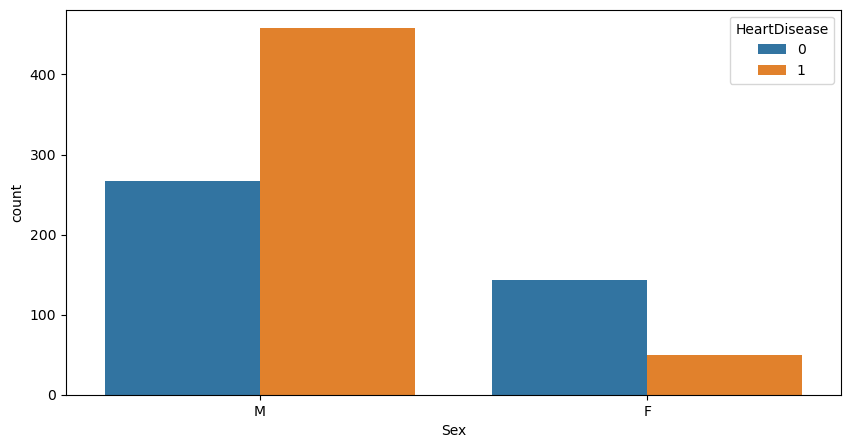

In [23]:
#graph on based sex
plt.figure(figsize= (10 , 5))
sns.countplot(x = 'Sex' , data = df , hue= 'HeartDisease')
plt.show()

In [24]:
df['ChestPainType'].value_counts()

ChestPainType
ASY    496
NAP    203
ATA    173
TA      46
Name: count, dtype: int64

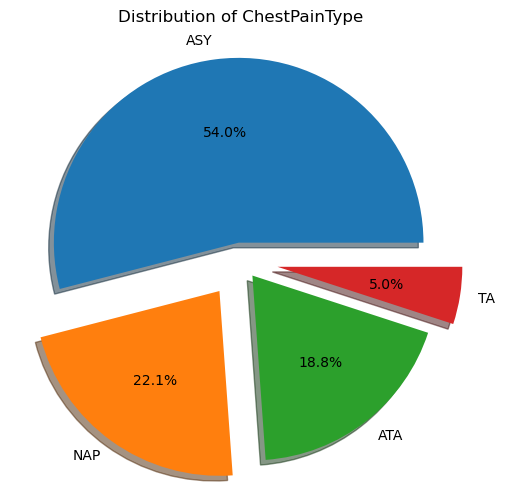

In [25]:
#pic chat of ChestPainType
counts = df['ChestPainType'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(counts, 
        labels=counts.index, 
        autopct='%.1f%%', 
        shadow=True, 
        explode=[0.1 , 0.2 , 0.1 , 0.2])

plt.title('Distribution of ChestPainType')
plt.show()

In [26]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0


In [27]:
df['RestingECG'].value_counts()

RestingECG
Normal    552
LVH       188
ST        178
Name: count, dtype: int64

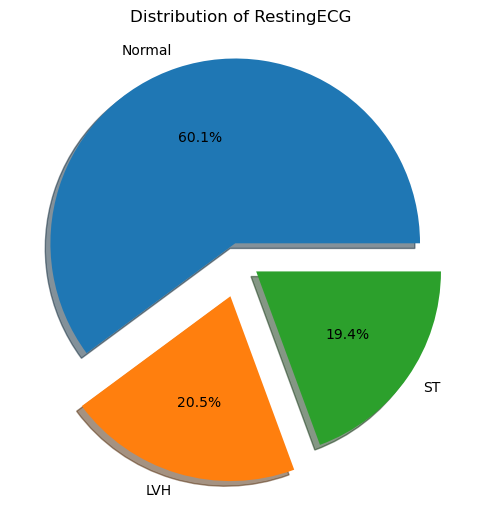

In [28]:
##pic chat of RestingECG
counts = df['RestingECG'].value_counts()

plt.figure(figsize=(10, 6))
plt.pie(counts, 
        labels=counts.index, 
        autopct='%.1f%%', 
        shadow=True, 
        explode=[0.1 , 0.2 , 0.1])

plt.title('Distribution of RestingECG')
plt.show()

In [29]:
df.describe()

,Age,RestingBP,Cholesterol,FastingBS,MaxHR,HeartDisease
count,918.000000,918.000000,918.000000,918.000000,918.000000,918.000000
mean,53.510893,132.540893,244.636253,0.233115,136.809368,0.553377
std,9.432617,17.989932,53.318029,0.423046,25.460334,0.497414
min,28.000000,80.000000,85.000000,0.000000,60.000000,0.000000
25%,47.000000,120.000000,214.000000,0.000000,120.000000,0.000000
50%,54.000000,130.000000,244.640000,0.000000,138.000000,1.000000
75%,60.000000,140.000000,267.000000,0.000000,156.000000,1.000000
max,77.000000,200.000000,603.000000,1.000000,202.000000,1.000000


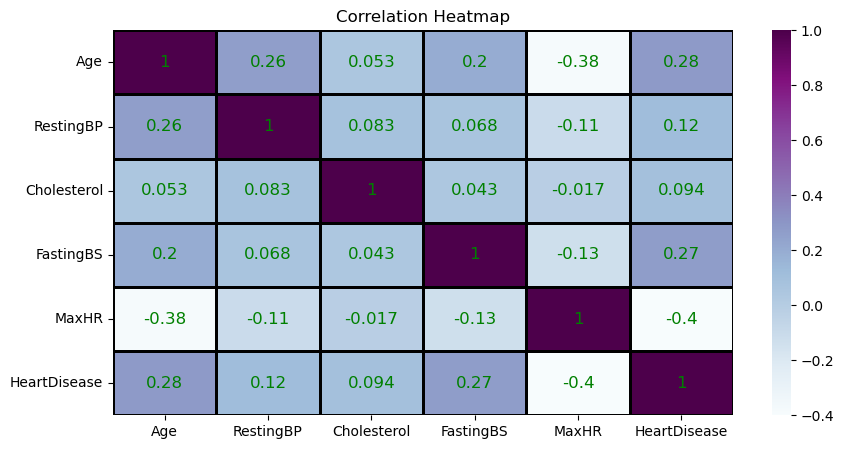

In [30]:
#heat map 
plt.figure(figsize=(10 , 5))
col = ['Age', 'RestingBP', 'Cholesterol', 'FastingBS',
       'MaxHR', 'HeartDisease']

v = sns.heatmap(
    df[col].corr(),
    annot=True,
    cmap='BuPu',
    annot_kws={'fontsize': 12, 'color': 'green'},
    linewidths=2,
    linecolor='black',
    xticklabels=True,
    yticklabels=True
)

v.set(title='Correlation Heatmap')

plt.show()

In [31]:
df.head()

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease
0,40,M,ATA,140.0,289.0,0,Normal,172,N,0
1,49,F,NAP,160.0,180.0,0,Normal,156,N,1
2,37,M,ATA,130.0,283.0,0,ST,98,N,0
3,48,F,ASY,138.0,214.0,0,Normal,108,Y,1
4,54,M,NAP,150.0,195.0,0,Normal,122,N,0


In [32]:
#label encoding and on-hot encoding
#LB-> sex , FastingBS ,ExerciseAngina
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

df['Sex'] = le.fit_transform(df['Sex'])
df['RestingECG'] = le.fit_transform(df['RestingECG'])
df['ExerciseAngina'] = le.fit_transform(df['ExerciseAngina'])

#on Hot Encoding 0n -> ChestPainType
df = pd.get_dummies(df, columns=['ChestPainType'], drop_first=True)

In [33]:
df.head(10)

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,1,140.0,289.0,0,1,172,0,0,True,False,False
1,49,0,160.0,180.0,0,1,156,0,1,False,True,False
2,37,1,130.0,283.0,0,2,98,0,0,True,False,False
3,48,0,138.0,214.0,0,1,108,1,1,False,False,False
4,54,1,150.0,195.0,0,1,122,0,0,False,True,False
5,39,1,120.0,339.0,0,1,170,0,0,False,True,False
6,45,0,130.0,237.0,0,1,170,0,0,True,False,False
7,54,1,110.0,208.0,0,1,142,0,0,True,False,False
8,37,1,140.0,207.0,0,1,130,1,1,False,False,False
9,48,0,120.0,284.0,0,1,120,0,0,True,False,False


In [34]:
df.columns

Index(['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG',
       'MaxHR', 'ExerciseAngina', 'HeartDisease', 'ChestPainType_ATA',
       'ChestPainType_NAP', 'ChestPainType_TA'],
      dtype='object')

In [35]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 918 entries, 0 to 917
Data columns (total 12 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Age                918 non-null    int64  
 1   Sex                918 non-null    int64  
 2   RestingBP          918 non-null    float64
 3   Cholesterol        918 non-null    float64
 4   FastingBS          918 non-null    int64  
 5   RestingECG         918 non-null    int64  
 6   MaxHR              918 non-null    int64  
 7   ExerciseAngina     918 non-null    int64  
 8   HeartDisease       918 non-null    int64  
 9   ChestPainType_ATA  918 non-null    bool   
 10  ChestPainType_NAP  918 non-null    bool   
 11  ChestPainType_TA   918 non-null    bool   
dtypes: bool(3), float64(2), int64(7)
memory usage: 67.4 KB


In [36]:
#train and test the model
from sklearn.model_selection import train_test_split

x = df[['Age', 'Sex', 'RestingBP', 'Cholesterol', 'FastingBS', 'RestingECG',
        'MaxHR', 'ExerciseAngina', 'ChestPainType_ATA',
        'ChestPainType_NAP', 'ChestPainType_TA']]

y = df['HeartDisease']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42, shuffle=True)

In [37]:
#Standard Scaling 
#SS -> RestingBP   , CholesterolMaxHR  , RestingECG , MaxHR	
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)

In [38]:
df.head()

,Age,Sex,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,HeartDisease,ChestPainType_ATA,ChestPainType_NAP,ChestPainType_TA
0,40,1,140.0,289.0,0,1,172,0,0,True,False,False
1,49,0,160.0,180.0,0,1,156,0,1,False,True,False
2,37,1,130.0,283.0,0,2,98,0,0,True,False,False
3,48,0,138.0,214.0,0,1,108,1,1,False,False,False
4,54,1,150.0,195.0,0,1,122,0,0,False,True,False


In [39]:
#logistic Regression
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
model = LogisticRegression()
model.fit(x_train , y_train)
L_pred = model.predict(x_test)
print('Logistic Prediction : ' ,  L_pred[:5])

# for i , val in enumerate(L_pred):
#     if val == 0:
#         print(f"patient{i}: Safe")
#     else:
#         print(f"patient{i}: Not Safe")

for i, (pred, actual) in enumerate(zip(L_pred, y_test), start=1):
    print(f"Patient {i} -> Predicted: {pred}, Actual: {actual}")


Logistic Prediction :  [0 0 1 1 0]
Patient 1 -> Predicted: 0, Actual: 0
Patient 2 -> Predicted: 0, Actual: 1
Patient 3 -> Predicted: 1, Actual: 1
Patient 4 -> Predicted: 1, Actual: 1
Patient 5 -> Predicted: 0, Actual: 0
Patient 6 -> Predicted: 1, Actual: 1
Patient 7 -> Predicted: 0, Actual: 1
Patient 8 -> Predicted: 0, Actual: 0
Patient 9 -> Predicted: 0, Actual: 1
Patient 10 -> Predicted: 1, Actual: 1
Patient 11 -> Predicted: 0, Actual: 0
Patient 12 -> Predicted: 1, Actual: 0
Patient 13 -> Predicted: 0, Actual: 0
Patient 14 -> Predicted: 0, Actual: 0
Patient 15 -> Predicted: 1, Actual: 1
Patient 16 -> Predicted: 1, Actual: 1
Patient 17 -> Predicted: 0, Actual: 0
Patient 18 -> Predicted: 1, Actual: 1
Patient 19 -> Predicted: 0, Actual: 1
Patient 20 -> Predicted: 0, Actual: 0
Patient 21 -> Predicted: 1, Actual: 1
Patient 22 -> Predicted: 1, Actual: 0
Patient 23 -> Predicted: 0, Actual: 0
Patient 24 -> Predicted: 1, Actual: 0
Patient 25 -> Predicted: 1, Actual: 1
Patient 26 -> Predicted:

In [40]:
#find matrices 
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
acc = accuracy_score(y_test , L_pred)
print('Accuracy Score : ' , round(acc , 2))

pre = precision_score(y_test , L_pred)
print('Precision Score : ' , round(pre , 2))

re = recall_score(y_test , L_pred)
print('Recall Score : ' ,round(re , 2))

f1 = f1_score(y_test , L_pred)
print('F1 Score : ' , round(f1 , 2) )

Accuracy Score :  0.81
Precision Score :  0.87
Recall Score :  0.79
F1 Score :  0.83


In [41]:
#Another Model test -> RandomForestClassifier
from sklearn.ensemble import RandomForestClassifier
modelr = RandomForestClassifier()
modelr.fit(x_train , y_train)
R_pred = modelr.predict(x_test)

print('Forest Predicated : ' , R_pred[:5])

for i ,(pred , actual) in enumerate(zip(R_pred , y_test) , start = 1):
    print(f"Patient {i} -> Predict:  {pred}  , Actual:  {actual}")


Forest Predicated :  [0 0 1 1 0]
Patient 1 -> Predict:  0  , Actual:  0
Patient 2 -> Predict:  0  , Actual:  1
Patient 3 -> Predict:  1  , Actual:  1
Patient 4 -> Predict:  1  , Actual:  1
Patient 5 -> Predict:  0  , Actual:  0
Patient 6 -> Predict:  1  , Actual:  1
Patient 7 -> Predict:  1  , Actual:  1
Patient 8 -> Predict:  1  , Actual:  0
Patient 9 -> Predict:  0  , Actual:  1
Patient 10 -> Predict:  1  , Actual:  1
Patient 11 -> Predict:  0  , Actual:  0
Patient 12 -> Predict:  0  , Actual:  0
Patient 13 -> Predict:  0  , Actual:  0
Patient 14 -> Predict:  0  , Actual:  0
Patient 15 -> Predict:  1  , Actual:  1
Patient 16 -> Predict:  1  , Actual:  1
Patient 17 -> Predict:  0  , Actual:  0
Patient 18 -> Predict:  1  , Actual:  1
Patient 19 -> Predict:  0  , Actual:  1
Patient 20 -> Predict:  0  , Actual:  0
Patient 21 -> Predict:  1  , Actual:  1
Patient 22 -> Predict:  1  , Actual:  0
Patient 23 -> Predict:  0  , Actual:  0
Patient 24 -> Predict:  0  , Actual:  0
Patient 25 -> Pr

In [42]:
#find matrices  of RandomForestClassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
acc = accuracy_score(y_test , R_pred)
print('Accuracy Score : ' , round(acc , 2))

pre = precision_score(y_test , R_pred)
print('Precision Score : ' , round(pre , 2))

re = recall_score(y_test , R_pred)
print('Recall Score : ' ,round(re , 2))

f1 = f1_score(y_test , R_pred)
print('F1 Score : ' , round(f1 , 2) )

Accuracy Score :  0.78
Precision Score :  0.83
Recall Score :  0.79
F1 Score :  0.81


In [51]:
# Another ModeL -> XGBclassifier
from xgboost import XGBClassifier
modelx = XGBClassifier()
modelx.fit(x_train , y_train)
X_pred = modelx.predict(x_test)

print('Forest Predicated : ' , X_pred[:5])

for i ,(pred , actual) in enumerate(zip(X_pred , y_test) , start = 1):
    print(f"Patient: {i} -> Predict: {pred} , Actual: {actual}")


Forest Predicated :  [0 1 1 1 0]
Patient: 1 -> Predict: 0 , Actual: 0
Patient: 2 -> Predict: 1 , Actual: 1
Patient: 3 -> Predict: 1 , Actual: 1
Patient: 4 -> Predict: 1 , Actual: 1
Patient: 5 -> Predict: 0 , Actual: 0
Patient: 6 -> Predict: 0 , Actual: 1
Patient: 7 -> Predict: 1 , Actual: 1
Patient: 8 -> Predict: 1 , Actual: 0
Patient: 9 -> Predict: 0 , Actual: 1
Patient: 10 -> Predict: 1 , Actual: 1
Patient: 11 -> Predict: 0 , Actual: 0
Patient: 12 -> Predict: 0 , Actual: 0
Patient: 13 -> Predict: 0 , Actual: 0
Patient: 14 -> Predict: 0 , Actual: 0
Patient: 15 -> Predict: 1 , Actual: 1
Patient: 16 -> Predict: 1 , Actual: 1
Patient: 17 -> Predict: 0 , Actual: 0
Patient: 18 -> Predict: 1 , Actual: 1
Patient: 19 -> Predict: 0 , Actual: 1
Patient: 20 -> Predict: 0 , Actual: 0
Patient: 21 -> Predict: 1 , Actual: 1
Patient: 22 -> Predict: 1 , Actual: 0
Patient: 23 -> Predict: 0 , Actual: 0
Patient: 24 -> Predict: 0 , Actual: 0
Patient: 25 -> Predict: 1 , Actual: 1
Patient: 26 -> Predict: 1 

In [44]:
#find matrices  of XGBclassifier
from sklearn.metrics import accuracy_score , precision_score , recall_score , f1_score
acc = accuracy_score(y_test , X_pred)
print('Accuracy Score : ' , round(acc , 2))

pre = precision_score(y_test , X_pred)
print('Precision Score : ' , round(pre , 2))

re = recall_score(y_test , X_pred)
print('Recall Score : ' ,round(re , 2))

f1 = f1_score(y_test , X_pred)
print('F1 Score : ' , round(f1 , 2) )

Accuracy Score :  0.77
Precision Score :  0.81
Recall Score :  0.79
F1 Score :  0.8


In [45]:
# finding all algorithum of accuarcy score
print("Logistic:", accuracy_score(y_test, L_pred))
print("Random Forest:", accuracy_score(y_test, R_pred))
print("XGBoost:", accuracy_score(y_test, X_pred))

Logistic: 0.8097826086956522
Random Forest: 0.782608695652174
XGBoost: 0.7717391304347826


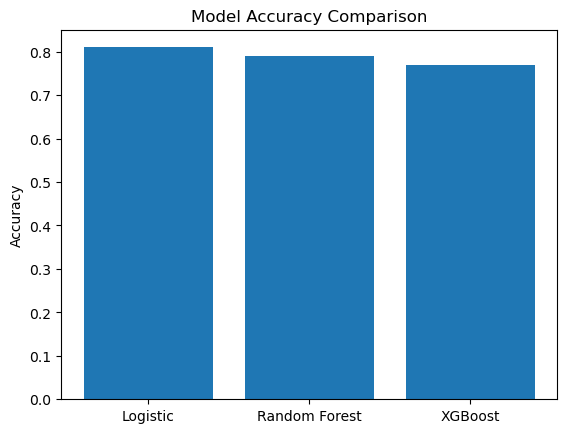

In [46]:
#graph b\w accuracy score 
models = ['Logistic', 'Random Forest', 'XGBoost']
accuracy = [0.81, 0.79, 0.77]

plt.bar(models, accuracy)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.show()

In [47]:
#finnding classificaton_report of all the algorithum 
from sklearn.metrics import classification_report
print('Classification Report of Logistic : \n', classification_report(y_test , L_pred))
print('Classification Report of Random Forest: \n', classification_report(y_test , R_pred))
print('Classification Report of XGBoost : \n', classification_report(y_test , X_pred))

Classification Report of Logistic : 
               precision    recall  f1-score   support

           0       0.74      0.83      0.79        77
           1       0.87      0.79      0.83       107

    accuracy                           0.81       184
   macro avg       0.81      0.81      0.81       184
weighted avg       0.82      0.81      0.81       184

Classification Report of Random Forest: 
               precision    recall  f1-score   support

           0       0.73      0.77      0.75        77
           1       0.83      0.79      0.81       107

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184

Classification Report of XGBoost : 
               precision    recall  f1-score   support

           0       0.72      0.74      0.73        77
           1       0.81      0.79      0.80       107

    accuracy                           0.77       184
   macro av

In [48]:
#confusion matrix ao all alogorithum
from sklearn.metrics import confusion_matrix

cmL = confusion_matrix(y_test , L_pred)
cmR = confusion_matrix(y_test , R_pred)
cmX = confusion_matrix(y_test , X_pred)

print('Confusion of Logistic : \n' , cmL)
print('Confusion of Forest : \n' , cmR)
print('Confusion of XGBoost : \n' , cmX)


Confusion of Logistic : 
 [[64 13]
 [22 85]]
Confusion of Forest : 
 [[59 18]
 [22 85]]
Confusion of XGBoost : 
 [[57 20]
 [22 85]]


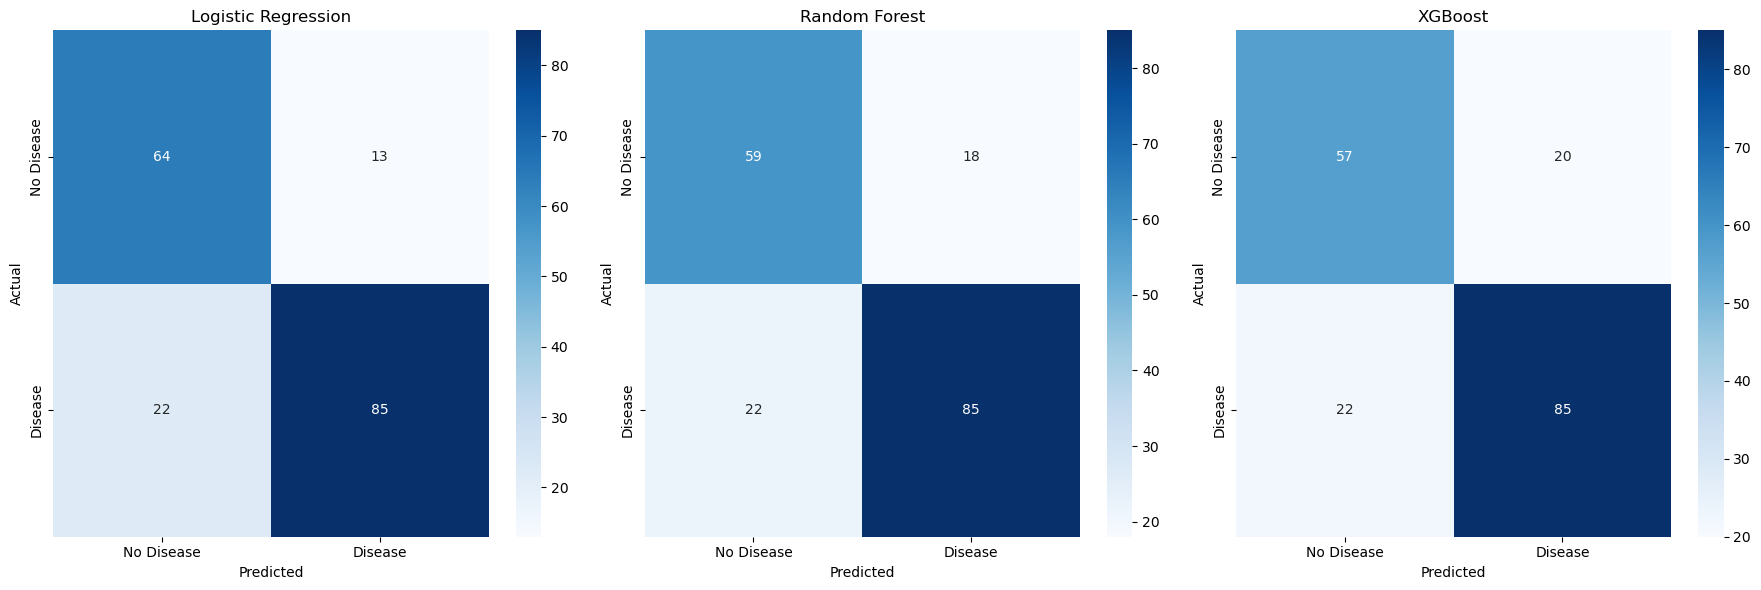

In [49]:
#heat map of all confusion matrix of all alorithums
plt.figure(figsize=(18, 6))

def plotting_heat(cm, title, num):
    plt.subplot(1, 3, num)
    sns.heatmap(cm, 
                annot=True, 
                fmt='d', 
                cmap='Blues',
                xticklabels=['No Disease', 'Disease'],
                yticklabels=['No Disease', 'Disease'])
    
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')

plotting_heat(cmL, 'Logistic Regression', 1)
plotting_heat(cmR, 'Random Forest', 2)
plotting_heat(cmX, 'XGBoost', 3)

plt.tight_layout()
plt.show()

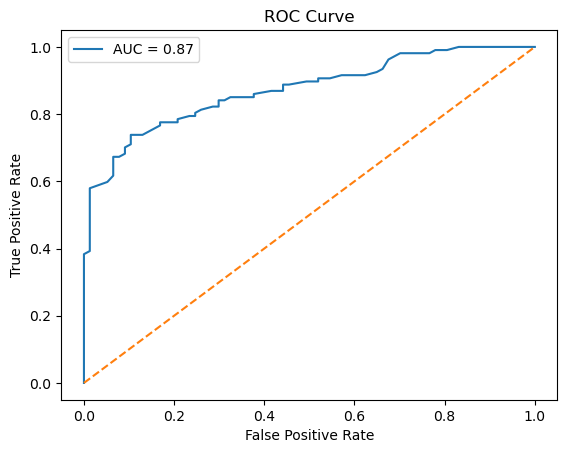

In [50]:
#roc of random foreset
from sklearn.metrics import roc_curve, auc

y_prob = modelr.predict_proba(x_test)[:,1]

fpr, tpr, _ = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'AUC = {roc_auc:.2f}')
plt.plot([0,1],[0,1],'--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.show()

In [52]:
import pickle 

In [53]:
pickle.dump(model , open('heart_model.pkl' , 'wb')) #model saving
pickle.dump(scaler , open('scaler.pkl' , 'wb')) # scaler saving